## Compare pairwise correlations between coSMicQC and PyOD ECOD flagged cells for the retransplantation plate

In [1]:
import time
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_density,
    geom_vline,
    ggplot,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option


In [2]:
# Set correlation cache directory to avoid rerunning every time
cache_dir = Path("corr_cache")
cache_dir.mkdir(exist_ok=True)


In [3]:
# Set figure directory
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True)


## Helper functions

In [4]:
# -----------------------------
# Cohen's d
# -----------------------------
def compute_cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    """
    Calculate Cohen's d effect size between two distributions.

    Args:
        x (np.ndarray):
            First distribution of values.
        y (np.ndarray):
            Second distribution of values.

    Returns:
        float:
            Cohen's d effect size.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    nx: int = len(x)
    ny: int = len(y)

    pooled_sd: float = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )

    return float((np.mean(x) - np.mean(y)) / pooled_sd)


def prep_pairwise(corr_matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Prepare the upper triangular indices and corresponding correlation values
    from a correlation matrix for further analysis.

    Args:
        corr_matrix (np.ndarray):
            A square correlation matrix.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]:
            - iu: Row indices of the upper triangular part of the matrix.
            - ju: Column indices of the upper triangular part of the matrix.
            - corr_matrix[iu, ju]: Corresponding correlation values.
    """
    n = corr_matrix.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    return iu, ju, corr_matrix[iu, ju]


def cohens_d_from_labels(
    iu: np.ndarray, ju: np.ndarray, corr_vals: np.ndarray, is_fail: np.ndarray
) -> float:
    fail_fail_mask = is_fail[iu] & is_fail[ju]
    pass_pass_mask = (~is_fail[iu]) & (~is_fail[ju])
    return compute_cohens_d(corr_vals[fail_fail_mask], corr_vals[pass_pass_mask])


# -----------------------------
# Fast vectorized permutation machinery between methods
#
# Both tests below share the same pooled cell population and the same
# precomputed correlation matrix, so a QC-method label is just a binary
# vector over that shared pool. Permuting the labels (while holding the
# number of "failed" cells fixed) gives the null distribution for a
# one-sided test of whether method A's summary statistic is greater than
# method B's.
# -----------------------------
def prep_corr_stats(
    corr_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Precompute the matrices needed for batched Cohen's d via quadratic forms.
    float32 for speed/memory; negligible precision loss for this purpose.

    Args:
        corr_matrix (np.ndarray):
            A square correlation matrix.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
            - C: The correlation matrix as float32.
            - C2: The element-wise square of the correlation matrix as float32.
            - C_rowsum: The sum of each row in the correlation matrix.
            - C2_rowsum: The sum of each row in the squared correlation matrix.
    """
    C = corr_matrix.astype(np.float32)
    C2 = (C**2).astype(np.float32)
    C_rowsum = C.sum(axis=1)
    C2_rowsum = C2.sum(axis=1)
    return C, C2, C_rowsum, C2_rowsum


def sample_label_matrix(
    rng: np.random.Generator, n_cells: int, n_fail: int, n_permutations: int
) -> np.ndarray:
    """
    Vectorized generation of `n_permutations` random binary label vectors,
    each with exactly `n_fail` ones out of `n_cells`, with no Python loop.

    Args:
        rng (np.random.Generator): A NumPy random number generator instance.
        n_cells (int): Total number of cells.
        n_fail (int): Number of failing cells (ones) in each permutation.
        n_permutations (int): Number of permutations to generate.

    Returns:
        np.ndarray: A binary matrix of shape (n_permutations, n_cells),
                    where each row is a random permutation of labels.
    """
    R = rng.random((n_permutations, n_cells)).astype(np.float32)
    thresh = np.partition(R, n_fail - 1, axis=1)[:, n_fail - 1]
    return (thresh[:, None] >= R).astype(np.float32)


def batch_failfail_stats(
    C: np.ndarray,
    C2: np.ndarray,
    C_rowsum: np.ndarray,  # noqa: ARG001
    C2_rowsum: np.ndarray,  # noqa: ARG001
    V: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Mean, variance, and pair count of within-group (failed-vs-failed)
    pairwise correlations, for one label vector per permutation.

    Args:
        C, C2, C_rowsum, C2_rowsum: Precomputed correlation statistics
            from `prep_corr_stats`.
        V (np.ndarray): Binary label matrix (P, n_cells); 1 = failed.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: mean, variance, and pair
            count of the failed-vs-failed correlations, per permutation.
    """
    Vt = V.T
    n_fail = V.sum(axis=1)

    CV = C @ Vt
    C2V = C2 @ Vt

    # subtract the diagonal (self-correlation = 1) then halve for the
    # upper-triangular pair count/sum
    sum_ff = ((Vt * CV).sum(axis=0) - n_fail) / 2
    sum_ff_sq = ((Vt * C2V).sum(axis=0) - n_fail) / 2
    count_ff = n_fail * (n_fail - 1) / 2

    mean_ff = sum_ff / count_ff
    var_ff = (sum_ff_sq - sum_ff**2 / count_ff) / (count_ff - 1)
    return mean_ff, var_ff, count_ff


def batch_cross_group_stats(
    C: np.ndarray,
    C2: np.ndarray,
    C_rowsum: np.ndarray,
    C2_rowsum: np.ndarray,
    V: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Mean, variance, and pair count of cross-group (failed-vs-passed)
    pairwise correlations, for one label vector per permutation.

    Args:
        C, C2, C_rowsum, C2_rowsum: Precomputed correlation statistics
            from `prep_corr_stats`.
        V (np.ndarray): Binary label matrix (P, n_cells); 1 = failed.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: mean, variance, and pair
            count of the failed-vs-passed correlations, per permutation.
    """
    Vt = V.T
    n_fail = V.sum(axis=1)
    n_pass = V.shape[1] - n_fail

    CV = C @ Vt
    C2V = C2 @ Vt
    CW = C_rowsum[:, None] - CV
    C2W = C2_rowsum[:, None] - C2V

    sum_cross = (Vt * CW).sum(axis=0)
    sum_cross_sq = (Vt * C2W).sum(axis=0)
    count_cross = n_fail * n_pass

    mean_cross = sum_cross / count_cross
    var_cross = (sum_cross_sq - sum_cross**2 / count_cross) / (count_cross - 1)
    return mean_cross, var_cross, count_cross


def cohens_d_from_group_stats(  # noqa: PLR0913
    mean_a: np.ndarray,
    var_a: np.ndarray,
    count_a: np.ndarray,
    mean_b: np.ndarray,
    var_b: np.ndarray,
    count_b: np.ndarray,
) -> np.ndarray:
    """Cohen's d between two groups' precomputed mean/variance/count."""
    pooled_sd = np.sqrt(
        ((count_a - 1) * var_a + (count_b - 1) * var_b) / (count_a + count_b - 2)
    )
    return (mean_a - mean_b) / pooled_sd


def permutation_test_between_methods_fast(  # noqa: PLR0913
    stats: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    is_fail_a: np.ndarray,
    is_fail_b: np.ndarray,
    stat_fn: Callable,
    alternative: str = "two-sided",
    n_permutations: int = 5000,
    seed: int = 0,
    batch_size: int = 1000,
) -> dict:
    """
    Permutation test comparing method A's and method B's pairwise-correlation
    statistic (`stat_fn`, e.g. failed-vs-failed or failed-vs-passed) over a
    shared pool of cells and a shared correlation matrix.

    Args:
        stats (tuple): Precomputed correlation statistics (C, C2, C_rowsum, C2_rowsum).
        is_fail_a (np.ndarray): Binary array indicating failing cells for method A.
        is_fail_b (np.ndarray): Binary array indicating failing cells for method B.
        stat_fn (Callable): `batch_failfail_stats` or `batch_cross_group_stats`.
        alternative (str): "two-sided", "greater" (A > B), or "less" (A < B).
        n_permutations (int): Number of permutations to perform.
        seed (int): Random seed for reproducibility.
        batch_size (int): Number of permutations to compute in each batch.

    Returns:
        dict: Observed Cohen's d (A vs B), the null distribution, and the p-value.
    """
    C, C2, C_rowsum, C2_rowsum = stats

    V_a_obs = is_fail_a[np.newaxis, :].astype(np.float32)
    V_b_obs = is_fail_b[np.newaxis, :].astype(np.float32)
    d_observed = cohens_d_from_group_stats(
        *stat_fn(C, C2, C_rowsum, C2_rowsum, V_a_obs),
        *stat_fn(C, C2, C_rowsum, C2_rowsum, V_b_obs),
    )[0]

    rng = np.random.default_rng(seed)
    n_cells = len(is_fail_a)
    n_fail_a = int(is_fail_a.sum())
    n_fail_b = int(is_fail_b.sum())

    null_d = np.empty(n_permutations)
    done = 0
    while done < n_permutations:
        cur = min(batch_size, n_permutations - done)
        V_a = sample_label_matrix(rng, n_cells, n_fail_a, cur)
        V_b = sample_label_matrix(rng, n_cells, n_fail_b, cur)
        null_d[done : done + cur] = cohens_d_from_group_stats(
            *stat_fn(C, C2, C_rowsum, C2_rowsum, V_a),
            *stat_fn(C, C2, C_rowsum, C2_rowsum, V_b),
        )
        done += cur

    if alternative == "greater":
        p_value = (np.sum(null_d >= d_observed) + 1) / (len(null_d) + 1)
    elif alternative == "less":
        p_value = (np.sum(null_d <= d_observed) + 1) / (len(null_d) + 1)
    else:
        p_value = (np.sum(np.abs(null_d) >= np.abs(d_observed)) + 1) / (len(null_d) + 1)

    return {"d_observed": d_observed, "null_distribution": null_d, "p_value": p_value}


# -----------------------------
# PACK FUNCTION
# -----------------------------
def pack(
    values: np.ndarray,
    method: str,
    comparison: str,
    iteration: int,
) -> pd.DataFrame:
    """
    Convert correlation values into long-format dataframe.

    Args:
        values (np.ndarray):
            Correlation values (pairwise or cross-group).
        method (str):
            QC method name ("ECOD" or "coSMicQC").
        comparison (str):
            Comparison type:
                - "Failed vs Failed"
                - "Passed vs Passed"
                - "Passed vs Failed"
        iteration (int):
            Bootstrap iteration index.

    Returns:
        pd.DataFrame:
            Long-format dataframe for plotting.
    """
    return pd.DataFrame(
        {
            "iteration": iteration,
            "correlation": values,
            "method": method,
            "comparison": comparison,
        }
    )


def classify_comparison(group: str) -> str:
    """Update the comparison groups for plotting

    Args:
        group (str): Original comparison group label

    Returns:
        str: New comparison label for plotting
    """
    if "Passed" in group and "Failed" in group:
        return "Passed vs failed cells"
    elif "Passed" in group and "Failed" not in group:
        return "Passed cells only"
    else:
        return "Failed cells only"


In [5]:
# Load QC-flag dataframes computed in Figure 3 panelA_UMAP_no_QC.ipynb
data_dir = Path("./data")
no_QC_df = pd.read_parquet(data_dir / "no_QC_df_with_ecod_flags.parquet")
cosmicqc_df = pd.read_parquet(data_dir / "cosmicqc_df_with_ecod_flags.parquet")


## Load in no QC feature-selected profile for retransplantation plate for pairwise comparison

In [6]:
# Load in feature selected QC profile for retransplanation plate (no_QC_fs_df)
no_QC_fs_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected_no_QC.parquet"
    )
)

# Based on coSMicQC_df, annotate the no_QC_fs_df with QC status from coSMicQC and ECOD
no_QC_fs_df = no_QC_fs_df.copy()
join_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Number_Object_Number",
]

# Add coSMicQC annotations
no_QC_fs_df = no_QC_fs_df.merge(
    cosmicqc_df[[*join_cols, "Metadata_QC_status", "coSMicQC_flag"]].drop_duplicates(),
    on=join_cols,
    how="left",
)

# Add ECOD annotations
no_QC_fs_df = no_QC_fs_df.merge(
    no_QC_df[[*join_cols, "ECOD_flag"]].drop_duplicates(),
    on=join_cols,
    how="left",
)

no_QC_fs_df.head()


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_03_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumVariance_ER_3_01_256,Nuclei_Texture_SumVariance_Hoechst_3_01_256,Nuclei_Texture_SumVariance_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_PM_3_01_256,Metadata_QC_status,coSMicQC_flag,ECOD_flag
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,0.906721,0.418794,0.385735,-0.133843,-0.363257,-0.262538,-0.309825,passed,0,0
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,-0.068447,0.437270,0.335719,-0.216157,-0.371891,2.526579,-0.183663,passed,0,0
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,0.454668,0.791982,0.541460,-0.121337,-0.395564,-0.234732,-0.316161,passed,0,0
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,0.206056,0.707142,0.398355,-0.164322,-0.366784,-0.150974,-0.212531,passed,0,0
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,-0.821989,0.978198,0.974789,-0.433306,-0.391546,0.044598,-0.349236,passed,0,0


## Separate in groups

In [7]:
# Extract feature columns
feature_cols = [
    col
    for col in no_QC_fs_df.columns
    if not col.startswith(
        (
            "Metadata_",
            "FileName",
            "ECOD_flag",
            "coSMicQC_flag",
        )
    )
]

# Create feature matrices for comparisons
failed_cosmicqc_features = no_QC_fs_df.loc[
    no_QC_fs_df["Metadata_QC_status"] == "failed",
    feature_cols,
]

passed_cosmicqc_features = no_QC_fs_df.loc[
    no_QC_fs_df["Metadata_QC_status"] == "passed",
    feature_cols,
]

failed_ecod_features = no_QC_fs_df.loc[
    no_QC_fs_df["ECOD_flag"] == 1,
    feature_cols,
]

passed_ecod_features = no_QC_fs_df.loc[
    no_QC_fs_df["ECOD_flag"] == 0,
    feature_cols,
]
# print counts
print("Original counts -")
print("cosmicqc failed:", len(failed_cosmicqc_features))
print("cosmicqc passed:", len(passed_cosmicqc_features))
print("ecod failed:", len(failed_ecod_features))
print("ecod passed:", len(passed_ecod_features))


Original counts -
cosmicqc failed: 4994
cosmicqc passed: 20865
ecod failed: 4991
ecod passed: 20868


In [8]:
rng = np.random.default_rng(0)

# COSMICQC: match passed size to failed size
n_cosmic_fail = len(failed_cosmicqc_features)

passed_cosmicqc_features = passed_cosmicqc_features.iloc[
    rng.choice(len(passed_cosmicqc_features), n_cosmic_fail, replace=False)
]

# ECOD: match passed size to failed size
n_ecod_fail = len(failed_ecod_features)

passed_ecod_features = passed_ecod_features.iloc[
    rng.choice(len(passed_ecod_features), n_ecod_fail, replace=False)
]

# print counts
print("Sampled data -")
print("cosmicqc failed:", len(failed_cosmicqc_features))
print("cosmicqc passed (matched):", len(passed_cosmicqc_features))

print("ecod failed:", len(failed_ecod_features))
print("ecod passed (matched):", len(passed_ecod_features))


Sampled data -
cosmicqc failed: 4994
cosmicqc passed (matched): 4994
ecod failed: 4991
ecod passed (matched): 4991


In [9]:
# Call dataframe plot dataframe for saving correlations
plot_path = cache_dir / "retranplant_plate_pairwise_corr_cosmic_ecod.parquet"

# -----------------------------
# SKIP IF ALREADY COMPUTED
# -----------------------------
if plot_path.exists():
    plot_df = pd.read_parquet(plot_path)
    print("Loaded existing plot_df:", plot_df.shape)

else:
    # -----------------------------
    # WITHIN-GROUP PAIRWISE CORRELATIONS
    # -----------------------------

    failed_cosmicqc_corr = np.corrcoef(failed_cosmicqc_features.values)
    passed_cosmicqc_corr = np.corrcoef(passed_cosmicqc_features.values)

    failed_ecod_corr = np.corrcoef(failed_ecod_features.values)
    passed_ecod_corr = np.corrcoef(passed_ecod_features.values)

    failed_cosmicqc_corr_values = failed_cosmicqc_corr[
        np.triu_indices_from(failed_cosmicqc_corr, k=1)
    ]

    passed_cosmicqc_corr_values = passed_cosmicqc_corr[
        np.triu_indices_from(passed_cosmicqc_corr, k=1)
    ]

    failed_ecod_corr_values = failed_ecod_corr[
        np.triu_indices_from(failed_ecod_corr, k=1)
    ]

    passed_ecod_corr_values = passed_ecod_corr[
        np.triu_indices_from(passed_ecod_corr, k=1)
    ]


    # -----------------------------
    # BETWEEN-GROUP PAIRWISE CORRELATIONS (FAST VECTORISED)
    # -----------------------------

    passed_failed_cosmicqc_corr = np.corrcoef(
        passed_cosmicqc_features.values,
        failed_cosmicqc_features.values
    )[:len(passed_cosmicqc_features), len(passed_cosmicqc_features):]

    passed_failed_ecod_corr = np.corrcoef(
        passed_ecod_features.values,
        failed_ecod_features.values
    )[:len(passed_ecod_features), len(passed_ecod_features):]


    passed_failed_cosmicqc_corr_values = passed_failed_cosmicqc_corr.ravel()
    passed_failed_ecod_corr_values = passed_failed_ecod_corr.ravel()


    # -----------------------------
    # Create plot dataframe and save
    # -----------------------------

    plot_df = pd.concat(
        [
            pd.DataFrame({
                "correlation": failed_cosmicqc_corr_values,
                "group": "Failed coSMicQC vs Failed coSMicQC",
            }),
            pd.DataFrame({
                "correlation": passed_cosmicqc_corr_values,
                "group": "Passed coSMicQC vs Passed coSMicQC",
            }),
            pd.DataFrame({
                "correlation": passed_failed_cosmicqc_corr_values,
                "group": "Passed coSMicQC vs Failed coSMicQC",
            }),
            pd.DataFrame({
                "correlation": failed_ecod_corr_values,
                "group": "Failed ECOD vs Failed ECOD",
            }),
            pd.DataFrame({
                "correlation": passed_ecod_corr_values,
                "group": "Passed ECOD vs Passed ECOD",
            }),
            pd.DataFrame({
                "correlation": passed_failed_ecod_corr_values,
                "group": "Passed ECOD vs Failed ECOD",
            }),
        ],
        ignore_index=True,
    )

    plot_df = (
        plot_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    plot_df.to_parquet(plot_path, index=False)
    print("Saved plot_df:", plot_df.shape)


Loaded existing plot_df: (99690249, 2)


In [10]:
# Print summary statistics on FULL dataset
summary_df = (
    plot_df.groupby("group")["correlation"].agg(["mean", "median", "std"]).round(3)
)
print(summary_df)


# Apply the new comparison labels for plotting
plot_df["qc_comparison"] = plot_df["group"].apply(classify_comparison)

# Create facet label (ECOD vs coSMicQC)
plot_df["comparison"] = plot_df["group"].apply(
    lambda x: "ECOD" if "ECOD" in x else "coSMicQC"
)


                                     mean  median    std
group                                                   
Failed ECOD vs Failed ECOD          0.052   0.021  0.298
Failed coSMicQC vs Failed coSMicQC  0.165   0.158  0.225
Passed ECOD vs Failed ECOD         -0.025  -0.051  0.205
Passed ECOD vs Passed ECOD          0.013   0.001  0.174
Passed coSMicQC vs Failed coSMicQC -0.059  -0.077  0.166
Passed coSMicQC vs Passed coSMicQC  0.023   0.014  0.191


Using 300,000 correlations for plotting (from 99,690,249 total correlations).


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 14 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/ECOD_vs_cosmicqc_correlation_comparisons.png


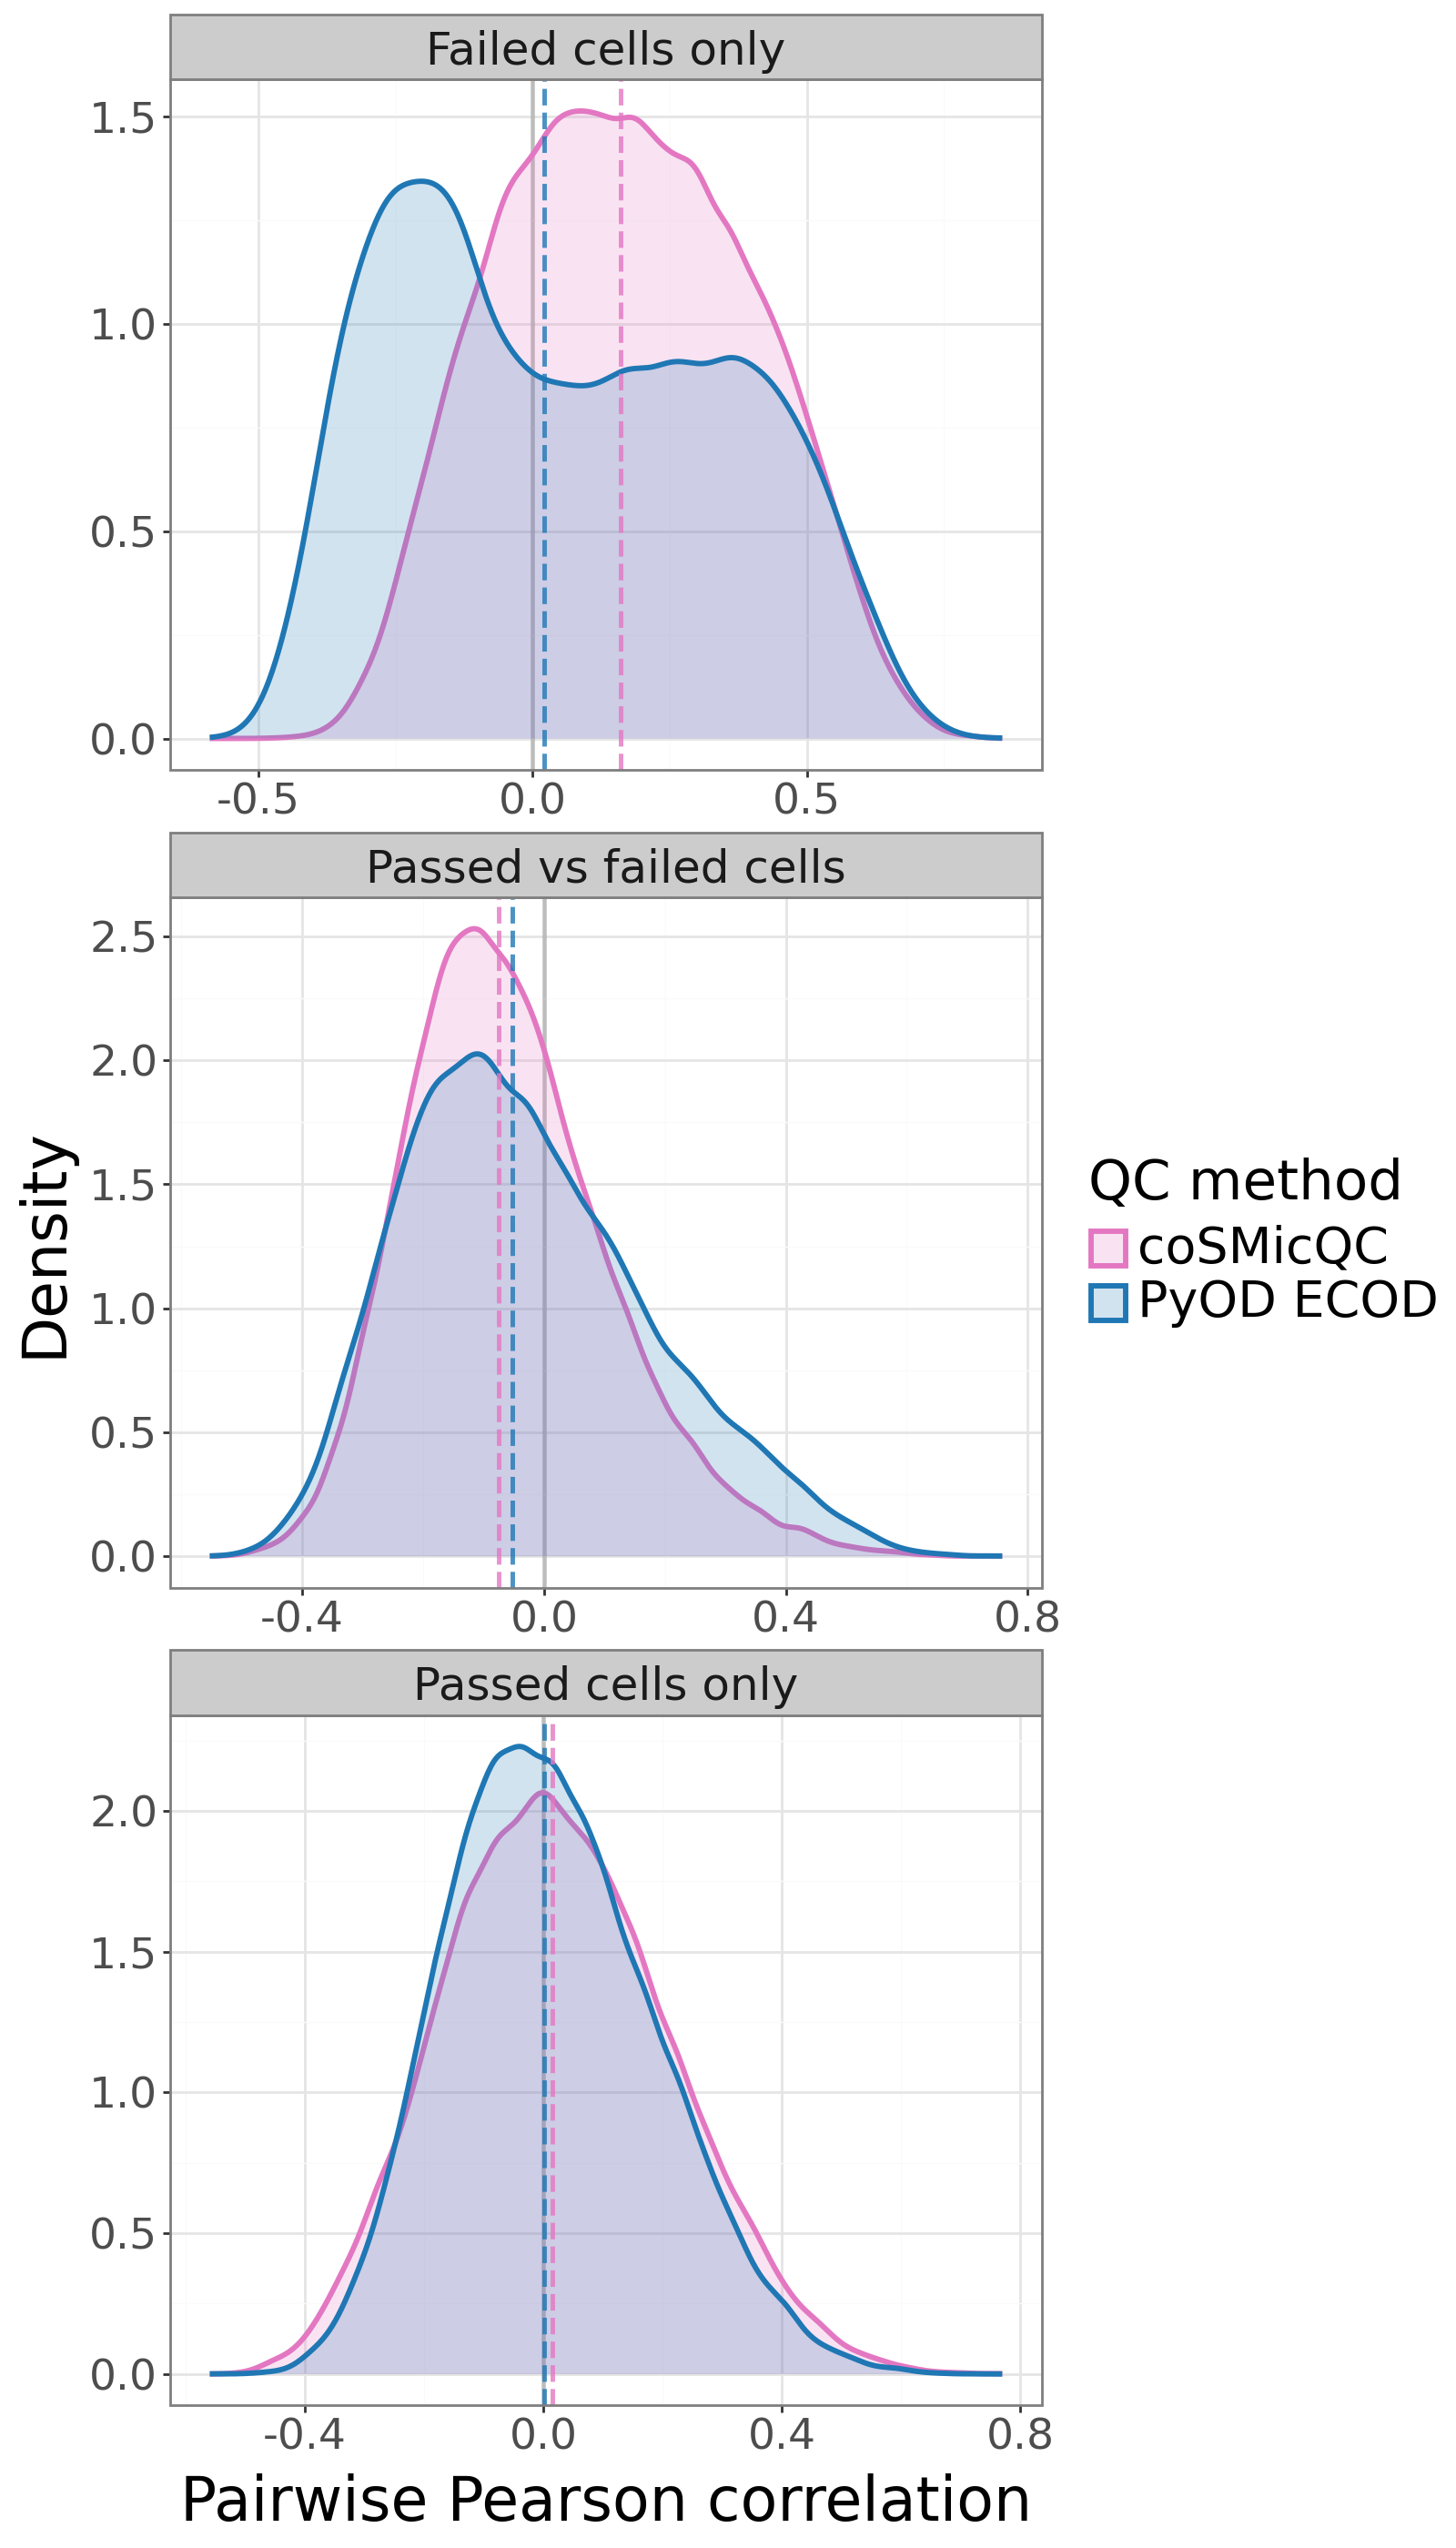

In [21]:
# -----------------------------
# Downsample for plotting only
# -----------------------------
# Use a large, reproducible subsample per group for KDE estimation.
# Summary statistics above are still calculated on the full dataset.

plot_df_plot = (
    plot_df.groupby("group", group_keys=False)
    .sample(
        n=min(
            50_000,
            plot_df.groupby("group").size().min(),
        ),
        random_state=0,
    )
    .reset_index(drop=True)
)

print(
    f"Using {len(plot_df_plot):,} correlations for plotting "
    f"(from {len(plot_df):,} total correlations)."
)

# Set the figure size (vertical stacked facet layout: tall, narrower)
# Bumped height slightly since we now have 3 facets instead of 2
height = 14
width = 8
set_option("figure_size", (width, height))

# median values for vertical lines
med_df = (
    plot_df_plot.groupby(["group", "comparison", "qc_comparison"])["correlation"]
    .median()
    .reset_index()
)

# Order facets: failed-only, passed-vs-failed, passed-only
plot_df_plot["qc_comparison"] = pd.Categorical(
    plot_df_plot["qc_comparison"],
    categories=["Failed cells only", "Passed vs failed cells", "Passed cells only"],
    ordered=True,
)

med_df["qc_comparison"] = pd.Categorical(
    med_df["qc_comparison"],
    categories=["Failed cells only", "Passed vs failed cells", "Passed cells only"],
    ordered=True,
)

# Order color/fill so coSMicQC and ECOD have a consistent legend order
plot_df_plot["comparison"] = pd.Categorical(
    plot_df_plot["comparison"],
    categories=["coSMicQC", "ECOD"],
    ordered=True,
)

med_df["comparison"] = pd.Categorical(
    med_df["comparison"],
    categories=["coSMicQC", "ECOD"],
    ordered=True,
)

# Plot
p = (
    ggplot(
        plot_df_plot,
        aes(
            x="correlation",
            color="comparison",
            fill="comparison",
        ),
    )
    + geom_vline(
        xintercept=0,
        color="grey",
        linetype="solid",
        size=1.0,
        alpha=0.4,
    )
    + geom_density(
        size=1.2,
        alpha=0.20,
    )
    + geom_vline(
        med_df,
        aes(
            xintercept="correlation",
            color="comparison",
        ),
        linetype="dashed",
        size=1.0,
        alpha=0.8,
        show_legend=False,
    )
    + facet_wrap(
        "~qc_comparison",
        scales="free",
        ncol=1,
        dir="v",
    )
    + scale_color_manual(
        values={
            "coSMicQC": "#E377C2",  # pink
            "ECOD": "#1F77B4",  # blue
        },
        labels={"coSMicQC": "coSMicQC", "ECOD": "PyOD ECOD"},
    )
    + scale_fill_manual(
        values={
            "coSMicQC": "#E377C2",  # pink
            "ECOD": "#1F77B4",  # blue
        },
        labels={"coSMicQC": "coSMicQC", "ECOD": "PyOD ECOD"},
    )
    + labs(
        x="Pairwise Pearson correlation",
        y="Density",
        color="QC method",
        fill="QC method",
    )
    + theme_bw()
    + theme(
        legend_position="right",
        axis_title=element_text(size=24),
        axis_text=element_text(size=17),
        strip_text=element_text(size=18),
        legend_title=element_text(size=22),
        legend_text=element_text(size=20),
    )
)

# Save the plot
p.save(
    figure_dir / "ECOD_vs_cosmicqc_correlation_comparisons.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()


In [12]:
# -----------------------------
# Calculate effect sizes from plot_df
# -----------------------------

d_cosmicqc = compute_cohens_d(
    plot_df.loc[
        plot_df["group"] == "Failed coSMicQC vs Failed coSMicQC",
        "correlation",
    ].to_numpy(),
    plot_df.loc[
        plot_df["group"] == "Passed coSMicQC vs Passed coSMicQC",
        "correlation",
    ].to_numpy(),
)

d_ecod = compute_cohens_d(
    plot_df.loc[
        plot_df["group"] == "Failed ECOD vs Failed ECOD",
        "correlation",
    ].to_numpy(),
    plot_df.loc[
        plot_df["group"] == "Passed ECOD vs Passed ECOD",
        "correlation",
    ].to_numpy(),
)

# -----------------------------
# Summary table
# -----------------------------
effect_size_df = pd.DataFrame(
    {
        "Method": ["coSMicQC", "ECOD"],
        "Comparison": ["Failed vs Passed", "Failed vs Passed"],
        "Cohens_d": [d_cosmicqc, d_ecod],
    }
)

print("Effect sizes:")
display(effect_size_df.round(3))

# -----------------------------
# Comparison
# -----------------------------
effect_size_difference = d_cosmicqc - d_ecod

print("\nComparison:")
print(f"coSMicQC Cohen's d: {d_cosmicqc:.3f}")
print(f"ECOD Cohen's d:     {d_ecod:.3f}")
print(f"Difference:         {effect_size_difference:.3f}")

if effect_size_difference > 0:
    print(
        f"\ncoSMicQC has the larger effect size by "
        f"{effect_size_difference:.3f} Cohen's d units."
    )
elif effect_size_difference < 0:
    print(
        f"\nECOD has the larger effect size by "
        f"{abs(effect_size_difference):.3f} Cohen's d units."
    )
else:
    print("\nBoth methods have identical effect sizes.")


Effect sizes:


,Method,Comparison,Cohens_d
0,coSMicQC,Failed vs Passed,0.680
1,ECOD,Failed vs Passed,0.163



Comparison:
coSMicQC Cohen's d: 0.680
ECOD Cohen's d:     0.163
Difference:         0.518

coSMicQC has the larger effect size by 0.518 Cohen's d units.


In [13]:
effect_size_ratio = d_cosmicqc / d_ecod

print(
    f"coSMicQC's effect size is {effect_size_ratio:.1f}× larger than ECOD's "
    f"(Cohen's d = {d_cosmicqc:.3f} vs {d_ecod:.3f})."
)


coSMicQC's effect size is 4.2× larger than ECOD's (Cohen's d = 0.680 vs 0.163).


In [14]:
# -----------------------------
# Calculate effect size from plot_df
# -----------------------------

d_pvf_both_methods = compute_cohens_d(
    plot_df.loc[
        plot_df["group"] == "Passed coSMicQC vs Failed coSMicQC",
        "correlation",
    ].to_numpy(),
    plot_df.loc[
        plot_df["group"] == "Passed ECOD vs Failed ECOD",
        "correlation",
    ].to_numpy(),
)

# -----------------------------
# Display result
# -----------------------------

effect_size_df = pd.DataFrame(
    {
        "Comparison": ["Passed coSMicQC vs Failed coSMicQC compared to Passed ECOD vs Failed ECOD"],
        "Cohens_d": [d_pvf_both_methods],
    }
)

display(effect_size_df.round(3))


,Comparison,Cohens_d
0,Passed coSMicQC vs Failed coSMicQC compared to...,-0.182


In [16]:
# -----------------------------
# Build shared cell pool for permutation testing
# -----------------------------
is_fail_cosmicqc_full = (no_QC_fs_df["Metadata_QC_status"] == "failed").to_numpy()
is_fail_ecod_full = (no_QC_fs_df["ECOD_flag"] == 1).to_numpy()

rng = np.random.default_rng(0)
failed_either = is_fail_cosmicqc_full | is_fail_ecod_full
passed_both = (~is_fail_cosmicqc_full) & (~is_fail_ecod_full)
failed_idx = np.where(failed_either)[0]
passed_idx = np.where(passed_both)[0]

n_passed_sample = min(len(passed_idx), len(failed_idx))
sampled_passed_idx = rng.choice(passed_idx, size=n_passed_sample, replace=False)

pool_idx = np.sort(np.concatenate([failed_idx, sampled_passed_idx]))
pool_df = no_QC_fs_df.iloc[pool_idx].reset_index(drop=True)

pool_X = pool_df[feature_cols]
pool_X_clean = pool_X.loc[:, ~pool_X.isna().any()]

corr_matrix_path = cache_dir / "pooled_population_corr_matrix.npy"

if corr_matrix_path.exists():
    corr_matrix = np.load(corr_matrix_path)
else:
    corr_matrix = np.corrcoef(pool_X_clean.values)
    np.save(corr_matrix_path, corr_matrix)

is_fail_cosmicqc = (pool_df["Metadata_QC_status"] == "failed").to_numpy()
is_fail_ecod = (pool_df["ECOD_flag"] == 1).to_numpy()

print(
    f"Pool size: {len(pool_df)} | coSMicQC fails: {is_fail_cosmicqc.sum()} | ECOD fails: {is_fail_ecod.sum()}"
)

# -----------------------------
# Precompute shared matrices ONCE, reuse across both tests
# -----------------------------
t0 = time.time()
stats = prep_corr_stats(corr_matrix)
print(f"prep_corr_stats: {time.time() - t0:.1f}s")

# -----------------------------
# Test 1: do cells that FAIL coSMicQC have significantly higher pairwise
# correlations than cells that FAIL PyOD ECOD? (one-sided, coSMicQC > ECOD)
# -----------------------------
t0 = time.time()
result_failfail = permutation_test_between_methods_fast(
    stats,
    is_fail_cosmicqc,
    is_fail_ecod,
    stat_fn=batch_failfail_stats,
    alternative="greater",
    n_permutations=10000,
    seed=0,
)

# -----------------------------
# Test 2: are PyOD ECOD's passed-vs-failed correlations significantly
# higher than coSMicQC's passed-vs-failed correlations? (one-sided, ECOD > coSMicQC)
# -----------------------------
result_cross_group = permutation_test_between_methods_fast(
    stats,
    is_fail_cosmicqc,
    is_fail_ecod,
    stat_fn=batch_cross_group_stats,
    alternative="less",
    n_permutations=10000,
    seed=0,
)
print(f"Both permutation tests: {time.time() - t0:.1f}s")

print(
    "\nFailed coSMicQC vs failed coSMicQC correlations > "
    "failed ECOD vs failed ECOD correlations:\n"
    "  d_observed:",
    round(result_failfail["d_observed"], 3),
    "| p =",
    round(result_failfail["p_value"], 4),
)
print(
    "\nPassed-vs-failed ECOD correlations > "
    "passed-vs-failed coSMicQC correlations:\n"
    "  d_observed:",
    round(result_cross_group["d_observed"], 3),
    "| p =",
    round(result_cross_group["p_value"], 4),
)


Pool size: 15296 | coSMicQC fails: 4994 | ECOD fails: 4991
prep_corr_stats: 0.6s
Both permutation tests: 68.0s

Failed coSMicQC vs failed coSMicQC correlations > failed ECOD vs failed ECOD correlations:
  d_observed: 0.426 | p = 0.0001

Passed-vs-failed ECOD correlations > passed-vs-failed coSMicQC correlations:
  d_observed: -0.208 | p = 0.0001
